<a href="https://colab.research.google.com/github/Prajkta11222/Market-Basket-Analysis-ML/blob/main/MARKET_BASKET_ML(CS23024%2CCS23031).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Market-Basket-Analysis-ML

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [150]:
import pandas as pd
url = "https://raw.githubusercontent.com/Prajkta11222/Market-Basket-Analysis-ML/refs/heads/main/DMart_Grocery_Sales_-_Retail_Analytics_Dataset.csv"
data = pd.read_csv(url)
data.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [151]:
data.shape

(9994, 11)

In [152]:
data.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

In [153]:
# Create artificial baskets (every 3 rows = 1 transaction)
transactions = [list(data['Sub Category'][i:i+3]) for i in range(0, len(data), 3)]

In [154]:
transactions[:5]

[['Masalas', 'Health Drinks', 'Atta & Flour'],
 ['Fresh Vegetables', 'Organic Staples', 'Organic Staples'],
 ['Fresh Vegetables', 'Fresh Fruits', 'Biscuits'],
 ['Cakes', 'Chocolates', 'Eggs'],
 ['Cookies', 'Fresh Vegetables', 'Chicken']]

In [155]:
!pip install mlxtend

In [156]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [157]:
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)
df.head()

,Atta & Flour,Biscuits,Breads & Buns,Cakes,Chicken,Chocolates,Cookies,Dals & Pulses,Edible Oil & Ghee,Eggs,...,Health Drinks,Masalas,Mutton,Noodles,Organic Fruits,Organic Staples,Organic Vegetables,Rice,Soft Drinks,Spices
0,True,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [158]:
item_counts = df.sum().sort_values(ascending=False)

item_counts.head(10)

,0
Health Drinks,668
Soft Drinks,631
Cookies,492
Chocolates,476
Breads & Buns,470
Noodles,467
Masalas,449
Cakes,440
Biscuits,437
Edible Oil & Ghee,435


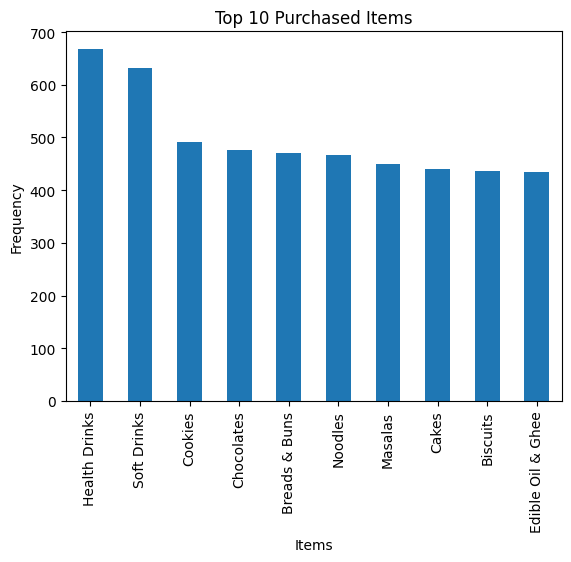

In [159]:

item_counts.head(10).plot(kind='bar')
plt.title("Top 10 Purchased Items")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.show()

Model 1: Apriori Algorithm

In [160]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)



In [161]:
# Add length column
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

In [162]:

# Show only itemsets with 2+ items
frequent_itemsets_2 = frequent_itemsets[frequent_itemsets['length'] > 1]
frequent_itemsets_2.head(10)

,support,itemsets,length
23,0.010804,"(Atta & Flour, Breads & Buns)",2
24,0.010804,"(Atta & Flour, Chocolates)",2
25,0.017107,"(Atta & Flour, Health Drinks)",2
26,0.010804,"(Atta & Flour, Masalas)",2
27,0.010804,"(Atta & Flour, Noodles)",2
28,0.011405,"(Atta & Flour, Organic Fruits)",2
29,0.010504,"(Atta & Flour, Soft Drinks)",2
30,0.014406,"(Breads & Buns, Biscuits)",2
31,0.016206,"(Biscuits, Cakes)",2
32,0.010204,"(Biscuits, Chicken)",2


MODEL 2:FP GROWTH


In [163]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import fpgrowth, association_rules

In [164]:
# Apply FP-Growth algorithm
# Lower support to get more item combinations
fp_items = fpgrowth(df, min_support=0.003, use_colnames=True)

In [165]:

# Add length column (to filter itemsets with more than 1 item)
fp_items['length'] = fp_items['itemsets'].apply(lambda x: len(x))


In [166]:

# Show only itemsets with 2 or more items
fp_items[fp_items['length'] > 1].head(10)

,support,itemsets,length
23,0.020708,"(Health Drinks, Masalas)",2
24,0.017707,"(Masalas, Soft Drinks)",2
25,0.012605,"(Masalas, Noodles)",2
26,0.015906,"(Masalas, Cookies)",2
27,0.011405,"(Masalas, Breads & Buns)",2
28,0.013806,"(Masalas, Chocolates)",2
29,0.017107,"(Atta & Flour, Health Drinks)",2
30,0.010804,"(Atta & Flour, Masalas)",2
31,0.006903,"(Atta & Flour, Fish)",2
32,0.007203,"(Atta & Flour, Fresh Vegetables)",2


In [167]:

# Generate association rules using confidence
fp_rules = association_rules(fp_items, metric="confidence", min_threshold=0.05)

In [168]:
# Select only important columns for clean output
fp_rules_clean = fp_rules[['antecedents','consequents','support','confidence','lift']]

In [169]:
# Display top rules
fp_rules_clean.head(10)

,antecedents,consequents,support,confidence,lift
0,(Health Drinks),(Masalas),0.020708,0.103293,0.766534
1,(Masalas),(Health Drinks),0.020708,0.153675,0.766534
2,(Masalas),(Soft Drinks),0.017707,0.131403,0.693875
3,(Soft Drinks),(Masalas),0.017707,0.093502,0.693875
4,(Masalas),(Noodles),0.012605,0.093541,0.667407
5,(Noodles),(Masalas),0.012605,0.089936,0.667407
6,(Masalas),(Cookies),0.015906,0.118040,0.799410
7,(Cookies),(Masalas),0.015906,0.107724,0.799410
8,(Masalas),(Breads & Buns),0.011405,0.084633,0.599991
9,(Breads & Buns),(Masalas),0.011405,0.080851,0.599991


In [170]:


# Filter strong rules (better for analysis)
strong_fp_rules = fp_rules_clean[
    (fp_rules_clean['confidence'] > 0.1) &
    (fp_rules_clean['lift'] > 0.7)
]


In [171]:
strong_fp_rules.sort_values(by='confidence', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
12,(Atta & Flour),(Health Drinks),0.017107,0.168142,0.838694
312,(Organic Vegetables),(Soft Drinks),0.015906,0.160606,0.848081
120,(Fresh Fruits),(Soft Drinks),0.016507,0.154494,0.815809
251,(Soft Drinks),(Health Drinks),0.029112,0.153724,0.766780
1,(Masalas),(Health Drinks),0.020708,0.153675,0.766534
461,(Rice),(Health Drinks),0.014406,0.153355,0.764937
274,(Dals & Pulses),(Soft Drinks),0.015306,0.153153,0.808726
277,(Dals & Pulses),(Health Drinks),0.015306,0.153153,0.763932
158,(Cakes),(Soft Drinks),0.020108,0.152273,0.804077
237,(Edible Oil & Ghee),(Soft Drinks),0.019508,0.149425,0.789041


Model 3: Eclat Algorithm

In [172]:
import pandas as pd

eclat_df = pd.DataFrame(list(frequent_items.items()), columns=['item', 'support'])

In [173]:
from itertools import combinations

comb_list = []

items = list(item_dict.keys())

for combo in combinations(items, 2):  # pairs only
    tids1 = item_dict[combo[0]]
    tids2 = item_dict[combo[1]]

    intersection = tids1 & tids2

    if len(intersection) >= min_support:
        comb_list.append((combo, len(intersection)))

In [174]:
comb_df = pd.DataFrame(comb_list, columns=['itemsets', 'support'])

In [175]:
comb_df.head(10)

,itemsets,support
0,"(Masalas, Health Drinks)",69
1,"(Masalas, Atta & Flour)",36
2,"(Masalas, Fresh Vegetables)",40
3,"(Masalas, Biscuits)",44
4,"(Masalas, Cakes)",43
5,"(Masalas, Chocolates)",46
6,"(Masalas, Cookies)",53
7,"(Masalas, Edible Oil & Ghee)",38
8,"(Masalas, Soft Drinks)",59
9,"(Masalas, Dals & Pulses)",42


Model 4: Association Rule Analysis

In [176]:

# Generate association rules from frequent itemsets
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

In [177]:

# Select only important columns (clean output)
rules_clean = rules[['antecedents','consequents','support','confidence','lift']]

In [178]:
# Show top rules sorted by confidence
rules_conf = rules_clean.sort_values(by='confidence', ascending=False)
rules_conf.head(10)

,antecedents,consequents,support,confidence,lift
4,(Atta & Flour),(Health Drinks),0.017107,0.168142,0.838694
261,(Organic Vegetables),(Soft Drinks),0.015906,0.160606,0.848081
207,(Fresh Fruits),(Soft Drinks),0.016507,0.154494,0.815809
233,(Soft Drinks),(Health Drinks),0.029112,0.153724,0.766780
219,(Masalas),(Health Drinks),0.020708,0.153675,0.766534
230,(Rice),(Health Drinks),0.014406,0.153355,0.764937
167,(Dals & Pulses),(Health Drinks),0.015306,0.153153,0.763932
170,(Dals & Pulses),(Soft Drinks),0.015306,0.153153,0.808726
93,(Cakes),(Soft Drinks),0.020108,0.152273,0.804077
183,(Edible Oil & Ghee),(Soft Drinks),0.019508,0.149425,0.789041


In [179]:
# Filter strong rules (better analysis)
strong_rules = rules_clean[
    (rules_clean['confidence'] > 0.1) &
    (rules_clean['lift'] > 0.7)
]

In [180]:
# Show strong rules sorted by confidence
strong_rules.sort_values(by='confidence', ascending=False).head(10)


,antecedents,consequents,support,confidence,lift
4,(Atta & Flour),(Health Drinks),0.017107,0.168142,0.838694
261,(Organic Vegetables),(Soft Drinks),0.015906,0.160606,0.848081
207,(Fresh Fruits),(Soft Drinks),0.016507,0.154494,0.815809
233,(Soft Drinks),(Health Drinks),0.029112,0.153724,0.766780
219,(Masalas),(Health Drinks),0.020708,0.153675,0.766534
230,(Rice),(Health Drinks),0.014406,0.153355,0.764937
167,(Dals & Pulses),(Health Drinks),0.015306,0.153153,0.763932
170,(Dals & Pulses),(Soft Drinks),0.015306,0.153153,0.808726
93,(Cakes),(Soft Drinks),0.020108,0.152273,0.804077
183,(Edible Oil & Ghee),(Soft Drinks),0.019508,0.149425,0.789041


In [181]:

# Show strong rules sorted by lift (important)
strong_rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
11,(Organic Fruits),(Atta & Flour),0.011405,0.113772,1.118259
10,(Atta & Flour),(Organic Fruits),0.011405,0.112094,1.118259
90,(Rice),(Cakes),0.011705,0.124601,0.943567
169,(Dals & Pulses),(Masalas),0.012605,0.126126,0.935974
17,(Cakes),(Biscuits),0.016206,0.122727,0.935760
16,(Biscuits),(Cakes),0.016206,0.123570,0.935760
107,(Chicken),(Spices),0.011705,0.116766,0.906913
176,(Mutton),(Edible Oil & Ghee),0.013205,0.116402,0.891613
177,(Edible Oil & Ghee),(Mutton),0.013205,0.101149,0.891613
117,(Fresh Fruits),(Chocolates),0.013505,0.126404,0.884831


Model 5 : K-Means Clustering

In [182]:

from sklearn.cluster import KMeans

In [183]:

# Convert True/False to 1/0 (important for K-Means)
df_kmeans = df.astype(int)

In [184]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(df_kmeans)

KMeans(n_clusters=3, random_state=42)

In [185]:
# Get cluster labels
labels = kmeans.labels_


In [186]:
# Add cluster column to dataset
df_kmeans['Cluster'] = labels

In [187]:
# Count data points in each cluster
df_kmeans['Cluster'].value_counts()

,count
Cluster,
0,1695
1,969
2,668


In [188]:

# Analyze clusters (mean values)
df_kmeans.groupby('Cluster').mean().head()

,Atta & Flour,Biscuits,Breads & Buns,Cakes,Chicken,Chocolates,Cookies,Dals & Pulses,Edible Oil & Ghee,Eggs,...,Health Drinks,Masalas,Mutton,Noodles,Organic Fruits,Organic Staples,Organic Vegetables,Rice,Soft Drinks,Spices
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.124484,0.163422,0.170501,0.164602,0.126254,0.171681,0.000000,0.124484,0.164012,0.135693,...,0.0,0.000000,0.148083,0.168732,0.125664,0.138643,0.126844,0.117994,0.231268,0.160472
1,0.073271,0.099071,0.116615,0.100103,0.077399,0.124871,0.432405,0.073271,0.100103,0.082559,...,0.0,0.392157,0.082559,0.122807,0.081527,0.091847,0.072239,0.067079,0.146543,0.100103
2,0.085329,0.095808,0.101796,0.095808,0.067365,0.095808,0.109281,0.076347,0.089820,0.079341,...,1.0,0.103293,0.070359,0.092814,0.062874,0.053892,0.067365,0.071856,0.145210,0.089820


Model 6: Recommendation System

In [189]:

from mlxtend.frequent_patterns import association_rules

In [190]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

In [191]:
rules[['antecedents','consequents','confidence','lift']].head()

,antecedents,consequents,confidence,lift
0,(Atta & Flour),(Breads & Buns),0.106195,0.752853
1,(Breads & Buns),(Atta & Flour),0.076596,0.752853
2,(Atta & Flour),(Chocolates),0.106195,0.743363
3,(Chocolates),(Atta & Flour),0.075630,0.743363
4,(Atta & Flour),(Health Drinks),0.168142,0.838694


In [192]:
def recommend(item):

    # Filter rules where item is present
    result = rules[
        rules['antecedents'].apply(lambda x: item in list(x)) |
        rules['consequents'].apply(lambda x: item in list(x))
    ]

    # If no result
    if result.empty:
        print("No recommendations found")
        return

    # Sort by confidence
    result = result.sort_values(by='confidence', ascending=False)

    # Return top 5 results
    return result[['antecedents','consequents','confidence','lift']].head(5)

In [193]:
recommend('Soft Drinks')
recommend('Cakes')
recommend('Masalas')
recommend('Breads & Buns')

,antecedents,consequents,confidence,lift
57,(Breads & Buns),(Health Drinks),0.144681,0.721672
66,(Breads & Buns),(Soft Drinks),0.134043,0.707813
55,(Fresh Vegetables),(Breads & Buns),0.120235,0.852387
69,(Spices),(Breads & Buns),0.118881,0.842791
15,(Biscuits),(Breads & Buns),0.109840,0.778694
